# Cuaderno 3 — Detección de Malware con Características PE

Este cuaderno implementa un sistema de detección de malware basado en
características estáticas de archivos ejecutables (PE — _Portable Executable_).

### Enfoque
1. Simular extracción de características PE (en producción se usa `pefile`).
2. Manejar el desbalanceo de clases con **SMOTE**.
3. Comparar tres clasificadores: **Árbol de Decisión**, **Random Forest**, **SVM**.
4. Interpretar los resultados con matrices de confusión e importancia de características.

### Características extraídas de un PE
| Característica | Descripción |
|---|---|
| `entry_point` | Dirección del punto de entrada |
| `num_sections` | Número de secciones en el ejecutable |
| `entropia_max` | Entropía máxima (alta → posible empaquetado/cifrado) |
| `num_importaciones` | Cantidad de funciones importadas |
| `num_dlls` | Número de DLLs importadas |
| `file_size` | Tamaño del archivo en bytes |
| `has_debug` | ¿Tiene información de depuración? |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
print("Importaciones OK")

Importaciones OK


## 1. Generación del dataset de características PE

Simulamos características típicas de 2 000 muestras:
- **1 700 benignas** — distribuciones moderadas, entropías bajas
- **300 maliciosas** — alta entropía (empaquetado), muchas importaciones, puntos
  de entrada en regiones inusuales

In [2]:
def generar_dataset_malware(n_benign=1700, n_malicious=300, seed=42):
    rng = np.random.default_rng(seed)

    benign = pd.DataFrame({
        "entry_point":       rng.integers(4096, 16384,   size=n_benign),
        "num_sections":      rng.integers(3, 7,           size=n_benign),
        "entropia_max":      rng.uniform(4.0, 6.5,        size=n_benign),
        "num_importaciones": rng.integers(20, 150,        size=n_benign),
        "num_dlls":          rng.integers(2, 12,          size=n_benign),
        "file_size":         rng.integers(50_000, 2_000_000, size=n_benign),
        "has_debug":         rng.integers(0, 2,           size=n_benign),
        "label":             0
    })

    malicious = pd.DataFrame({
        "entry_point":       rng.integers(0, 4096,        size=n_malicious),
        "num_sections":      rng.integers(8, 20,          size=n_malicious),
        "entropia_max":      rng.uniform(6.8, 8.0,        size=n_malicious),
        "num_importaciones": rng.integers(200, 600,       size=n_malicious),
        "num_dlls":          rng.integers(15, 40,         size=n_malicious),
        "file_size":         rng.integers(10_000, 500_000, size=n_malicious),
        "has_debug":         np.zeros(n_malicious, dtype=int),
        "label":             1
    })

    df = pd.concat([benign, malicious], ignore_index=True).sample(frac=1, random_state=seed)
    return df

df = generar_dataset_malware()
print(f"Dataset: {df.shape}")
print(f"  Benign:    {(df.label==0).sum()}  ({(df.label==0).mean()*100:.1f}%)")
print(f"  Malicious: {(df.label==1).sum()}  ({(df.label==1).mean()*100:.1f}%)")
df.describe()

Dataset: (2000, 8)
  Benign:    1700  (85.0%)
  Malicious: 300  (15.0%)


,entry_point,num_sections,entropia_max,num_importaciones,num_dlls,file_size,has_debug,label
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000
mean,9044.940500,5.835000,5.559526,130.512500,9.676000,9.126384e+05,0.402500,0.150000
std,4412.251771,3.650951,1.032185,123.847378,8.393941,5.873334e+05,0.490524,0.357161
min,56.000000,3.000000,4.001420,20.000000,2.000000,1.065900e+04,0.000000,0.000000
25%,5543.000000,4.000000,4.705120,58.000000,5.000000,3.682272e+05,0.000000,0.000000
50%,9349.000000,5.000000,5.457076,93.500000,7.000000,8.577675e+05,0.000000,0.000000
75%,12868.750000,6.000000,6.208910,133.000000,10.000000,1.428190e+06,1.000000,0.000000
max,16372.000000,19.000000,7.999833,599.000000,39.000000,1.998947e+06,1.000000,1.000000


## 2. Análisis exploratorio de las características

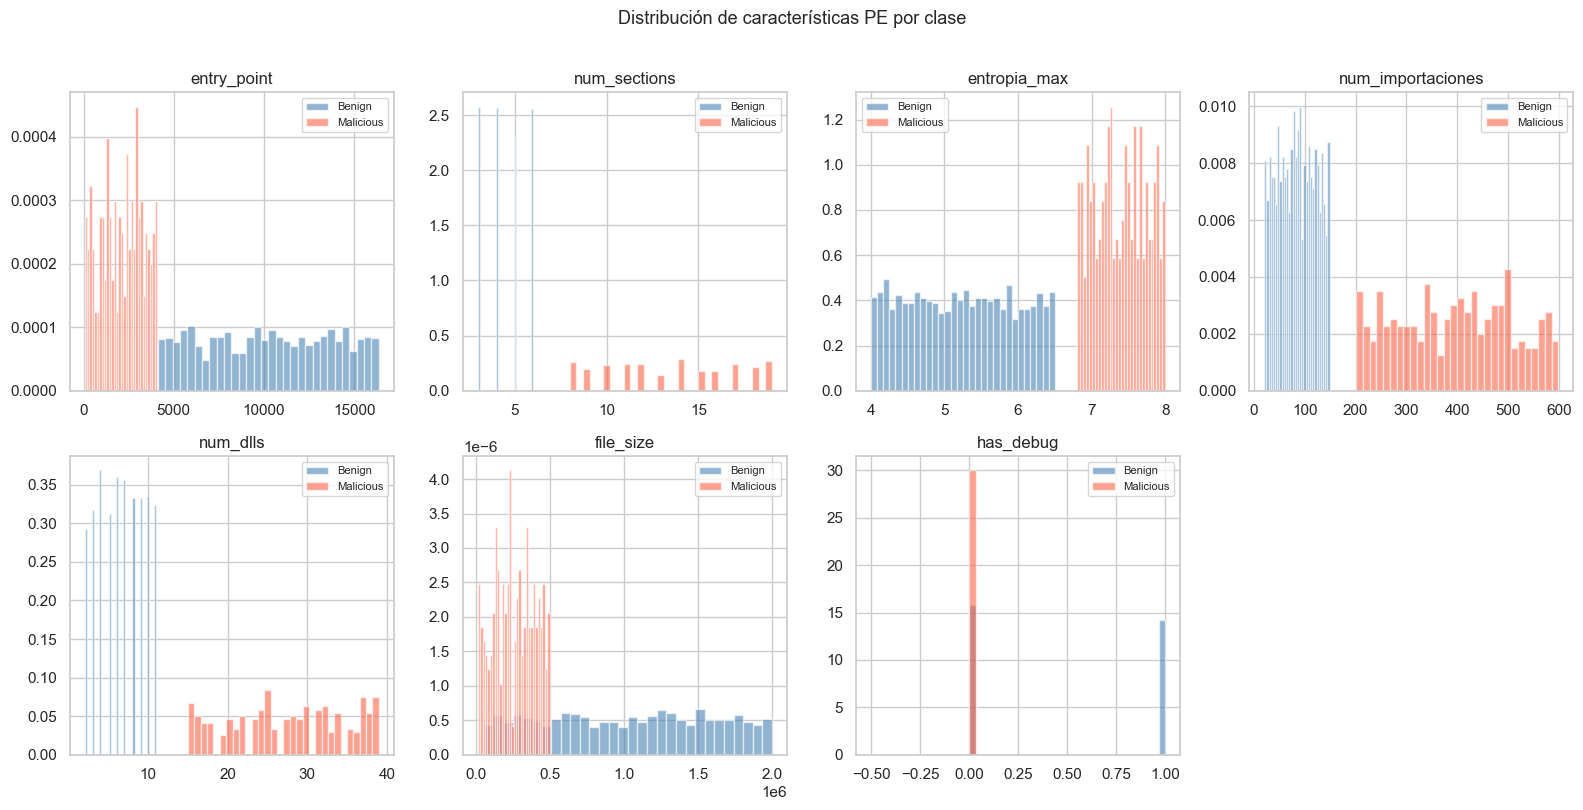

In [3]:
FEATURES = ["entry_point", "num_sections", "entropia_max",
            "num_importaciones", "num_dlls", "file_size", "has_debug"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    for label, color, name in [(0, "steelblue", "Benign"), (1, "tomato", "Malicious")]:
        subset = df[df.label == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

axes[-1].axis("off")
plt.suptitle("Distribución de características PE por clase", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Preparación de datos y aplicación de SMOTE

**SMOTE** (Synthetic Minority Oversampling TEchnique) genera muestras sintéticas
de la clase minoritaria interpolando entre vecinos cercanos. Evita que el modelo
ignore la clase de malware por ser minoritaria.

Train — Benign: 1360, Malicious: 240
Tras SMOTE — Benign: 1360, Malicious: 1360


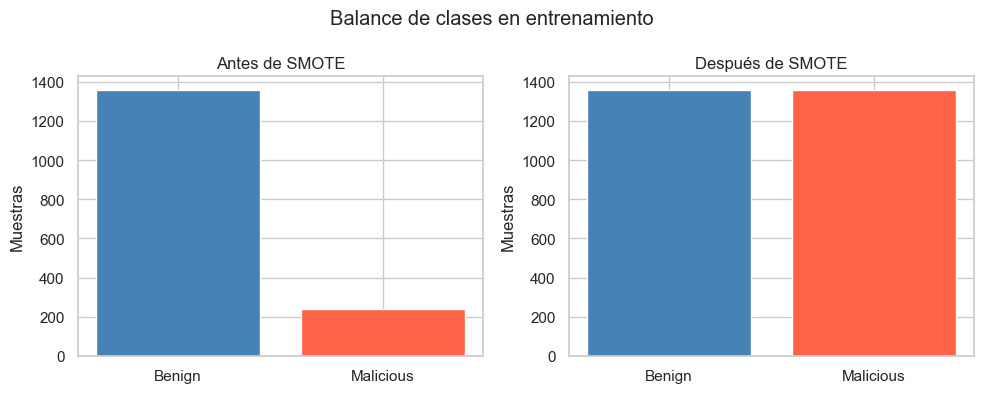

In [4]:
X = df[FEATURES]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Train — Benign: {(y_train==0).sum()}, Malicious: {(y_train==1).sum()}")

# Aplicar SMOTE al conjunto de entrenamiento
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Tras SMOTE — Benign: {(y_train_res==0).sum()}, Malicious: {(y_train_res==1).sum()}")

# Visualizar balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), "Antes de SMOTE"),
    (pd.Series(y_train_res).value_counts(), "Después de SMOTE")
]):
    ax.bar(["Benign", "Malicious"], [counts.get(0,0), counts.get(1,0)],
           color=["steelblue", "tomato"])
    ax.set_title(title)
    ax.set_ylabel("Muestras")
plt.suptitle("Balance de clases en entrenamiento")
plt.tight_layout()
plt.show()

## 4. Entrenamiento y evaluación de tres clasificadores


Modelo: Árbol de Decisión
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       340
   Malicious       1.00      1.00      1.00        60

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



F1 CV-5: 1.0000 ± 0.0000



Modelo: Random Forest
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       340
   Malicious       1.00      1.00      1.00        60

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



F1 CV-5: 1.0000 ± 0.0000

Modelo: SVM (RBF)
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       340
   Malicious       1.00      1.00      1.00        60

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



F1 CV-5: 1.0000 ± 0.0000


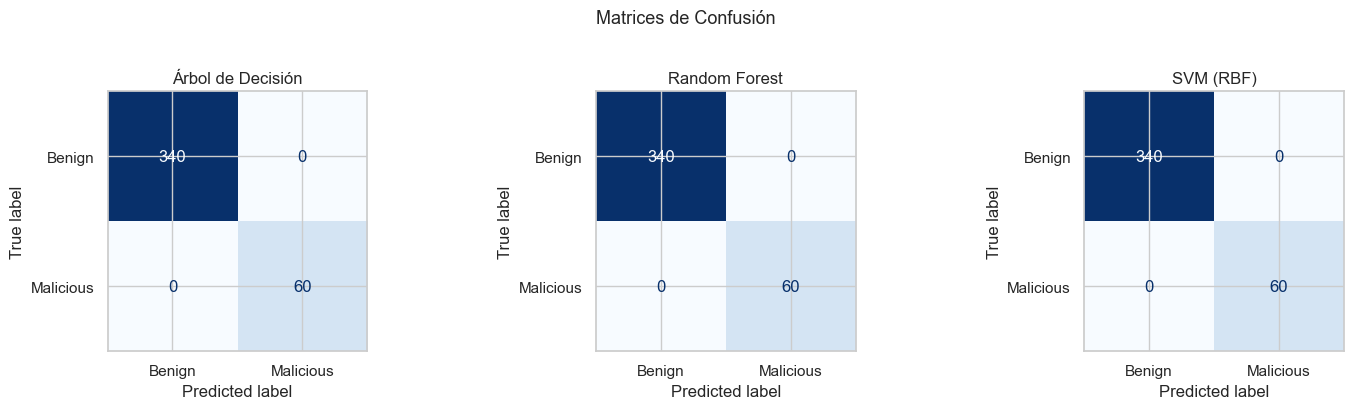

In [5]:
def evaluar_modelo(nombre, clf, X_tr, y_tr, X_te, y_te, ax_cm=None):
    """Entrena, evalúa y reporta métricas de un clasificador."""
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    
    print(f"\n{'='*50}")
    print(f"Modelo: {nombre}")
    print("="*50)
    print(classification_report(y_te, y_pred, target_names=["Benign", "Malicious"]))
    
    # Validación cruzada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_f1 = cross_val_score(clf, X_tr, y_tr, cv=cv, scoring="f1", n_jobs=-1)
    print(f"F1 CV-5: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    
    # Matriz de confusión
    if ax_cm is not None:
        cm = confusion_matrix(y_te, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malicious"])
        disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
        ax_cm.set_title(nombre)
    
    return clf

# Definir modelos
modelos = {
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=10, random_state=SEED),
    "Random Forest":     RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(kernel="rbf", random_state=SEED))
    ]),
}

fig, axes_cm = plt.subplots(1, 3, figsize=(15, 4))
clfs_entrenados = {}
for (nombre, clf), ax in zip(modelos.items(), axes_cm):
    clfs_entrenados[nombre] = evaluar_modelo(
        nombre, clf, X_train_res, y_train_res, X_test, y_test, ax_cm=ax
    )

plt.suptitle("Matrices de Confusión", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Curvas ROC y comparación final

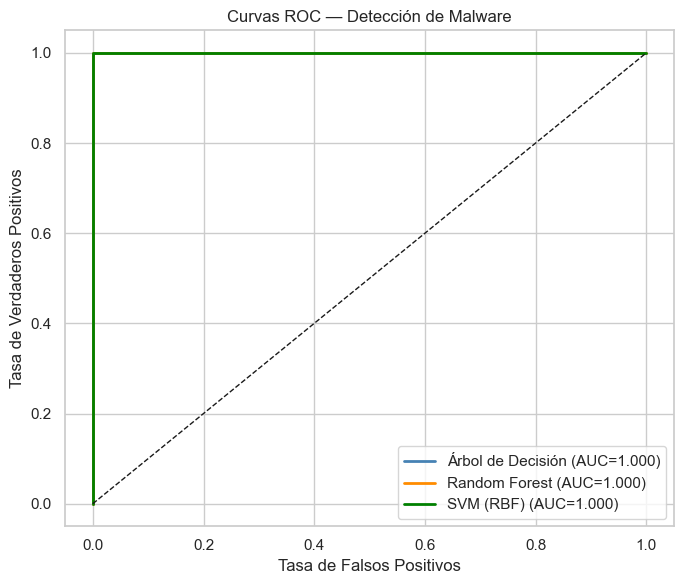


✓ Cuaderno 3 completado.


In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
colores = ["steelblue", "darkorange", "green"]

for (nombre, clf), color in zip(clfs_entrenados.items(), colores):
    # predict_proba o decision_function
    if hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X_test)[:, 1]
    else:
        scores = clf.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{nombre} (AUC={auc:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — Detección de Malware")
ax.legend()
plt.tight_layout()
plt.show()

print("\n✓ Cuaderno 3 completado.")

## 6. Importancia de características (Random Forest)

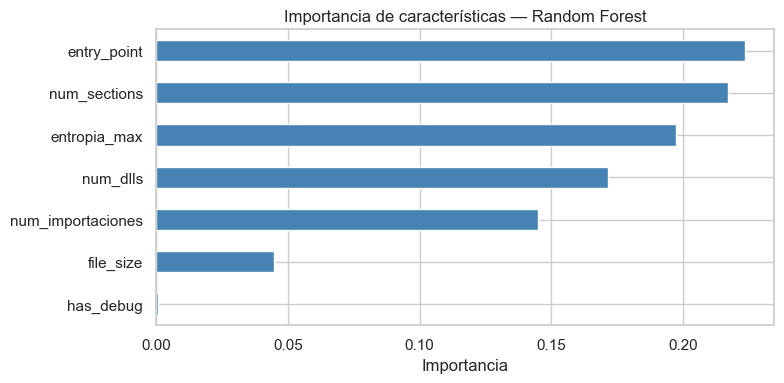

Característica más discriminante: entry_point


In [7]:
rf_model = clfs_entrenados["Random Forest"]
importancias = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Importancia de características — Random Forest")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

print("Característica más discriminante:", importancias.idxmax())